In [4]:
from ultralytics import YOLO
import cv2
import math
from PIL import Image
from IPython.display import display, clear_output

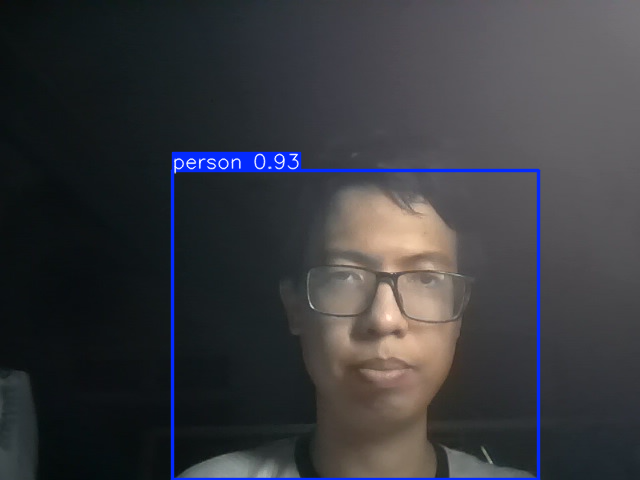

KeyboardInterrupt: 

In [13]:
# 1. Load the YOLO model (nano version is fast for real-time)
model = YOLO('yolo26n.pt')  # or 'yolo11n.pt'

# 2. Open the webcam (0 is usually the default camera)
cap = cv2.VideoCapture(0)

# Set resolution (optional)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

while True:
    # 3. Read frame from webcam
    ret, frame = cap.read()
    if not ret:
        break

    # 4. Perform YOLO detection on the frame
    # stream=True optimizes memory usage for video
    results = model(frame, stream=True)

    # 5. Visualize results on the frame
    for r in results:
        annotated_frame = r.plot()

    # 6. Display the frame
    # Convert the numpy array (BGR) to a PIL Image (RGB)
    clear_output()
    img = Image.fromarray(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    display(img)

    # 7. Press 'q' to break the loop and exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 8. Release resources
cap.release()
cv2.destroyAllWindows()